# Parte 2: Regresión Lineal Simple

## Dataset: Salary Dataset

El objetivo de esta práctica es construir un modelo de Regresión Lineal Simple para predecir el salario de un empleado a partir de sus años de experiencia.

La variable independiente será:

- `YearsExperience`: años de experiencia laboral

La variable dependiente será:

- `Salary`: salario anual

Durante el notebook se realizará:

1. Carga del dataset.
2. Exploración inicial de los datos.
3. Análisis exploratorio.
4. Preparación de variables.
5. Entrenamiento del modelo.
6. Evaluación con métricas de regresión.
7. Análisis de residuos.
8. Predicciones nuevas.

In [ ]:
# Instalamos kagglehub para descargar el dataset desde Kaggle
!pip install kagglehub

In [ ]:
# Importamos las librerías necesarias

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

print("Librerías cargadas correctamente")

Librerías cargadas correctamente


In [ ]:
# Descargamos el dataset desde Kaggle

path = kagglehub.dataset_download("abhishek14398/salary-dataset-simple-linear-regression")

print("Path to dataset files:", path)
print("Archivos descargados:", os.listdir(path))

100%|██████████| 457/457 [00:00<00:00, 930kB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/abhishek14398/salary-dataset-simple-linear-regression/versions/1
Archivos descargados: ['Salary_dataset.csv']


In [ ]:
# Cargamos el archivo CSV

csv_path = os.path.join(path, "Salary_dataset.csv")

df = pd.read_csv(csv_path)

print("Primeras 5 filas del dataset:")
display(df.head())

Primeras 5 filas del dataset:


,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [ ]:
# Revisamos dimensiones del dataset

print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Número de filas: 30
Número de columnas: 3


In [ ]:
# Información general del dataset

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       30 non-null     int64  
 1   YearsExperience  30 non-null     float64
 2   Salary           30 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 852.0 bytes


In [ ]:
# Valores nulos por columna

print("Valores nulos por columna:")
display(df.isnull().sum())

Valores nulos por columna:


,0
Unnamed: 0,0
YearsExperience,0
Salary,0


In [ ]:
# Estadísticas descriptivas

print("Estadísticas descriptivas:")
display(df.describe().round(2))

Estadísticas descriptivas:


,Unnamed: 0,YearsExperience,Salary
count,30.00,30.00,30.00
mean,14.50,5.41,76004.00
std,8.80,2.84,27414.43
min,0.00,1.20,37732.00
25%,7.25,3.30,56721.75
50%,14.50,4.80,65238.00
75%,21.75,7.80,100545.75
max,29.00,10.60,122392.00


In [ ]:
# Eliminamos la columna Unnamed: 0 porque solo representa el índice original del archivo

df = df.drop(columns=["Unnamed: 0"])

print("Columnas finales del dataset:")
print(df.columns.tolist())

display(df.head())

Columnas finales del dataset:
['YearsExperience', 'Salary']


,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


## Observaciones iniciales

El dataset contiene 30 registros y, tras eliminar la columna `Unnamed: 0`, quedan 2 variables relevantes:

- `YearsExperience`: años de experiencia del empleado.
- `Salary`: salario anual.

No hay valores nulos en ninguna columna, por lo que no es necesario imputar ni eliminar registros por datos faltantes.

La variable `YearsExperience` va aproximadamente desde 1.2 hasta 10.6 años. La variable `Salary` va desde 37,732 hasta 122,392. Esto sugiere que el dataset contiene empleados con distintos niveles de experiencia y salarios, lo cual permite analizar si existe una relación lineal entre ambas variables.

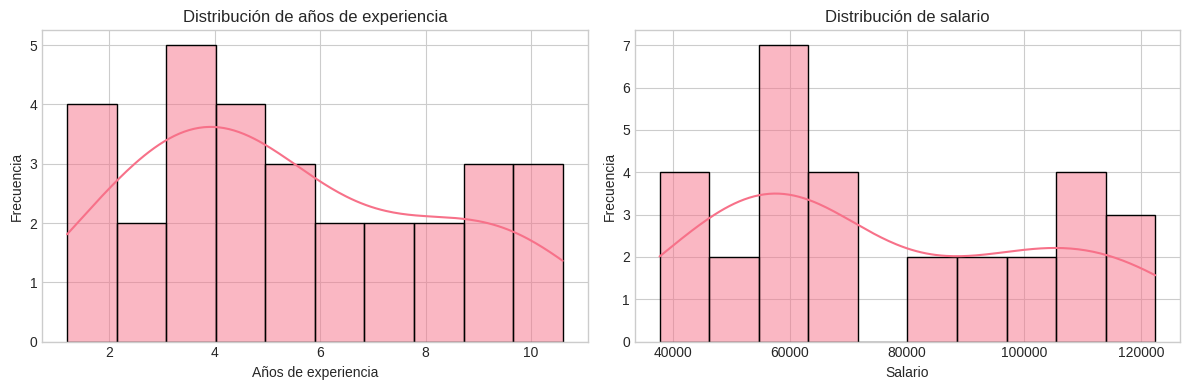

In [ ]:
# Histogramas de las dos variables principales

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(data=df, x="YearsExperience", bins=10, kde=True, ax=axes[0])
axes[0].set_title("Distribución de años de experiencia")
axes[0].set_xlabel("Años de experiencia")
axes[0].set_ylabel("Frecuencia")

sns.histplot(data=df, x="Salary", bins=10, kde=True, ax=axes[1])
axes[1].set_title("Distribución de salario")
axes[1].set_xlabel("Salario")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

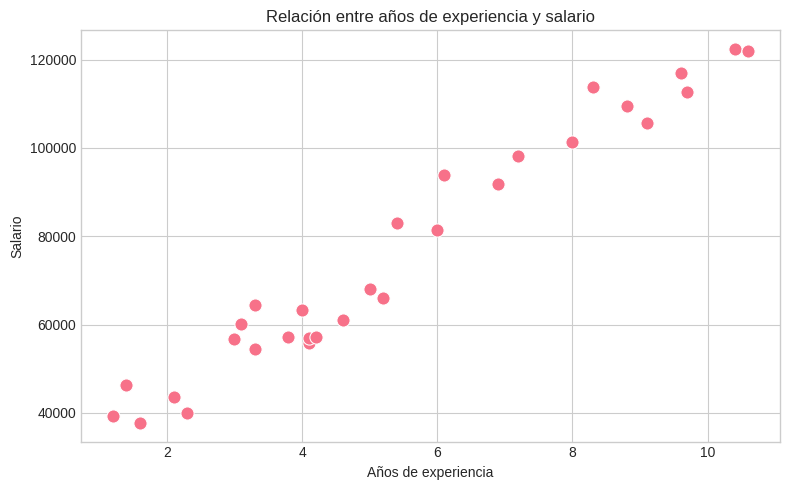

In [ ]:
# Scatter plot para analizar la relación entre experiencia y salario

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="YearsExperience",
    y="Salary",
    s=90
)

plt.title("Relación entre años de experiencia y salario")
plt.xlabel("Años de experiencia")
plt.ylabel("Salario")
plt.tight_layout()
plt.show()

In [ ]:
# Correlación de Pearson entre las variables

correlacion = df["YearsExperience"].corr(df["Salary"])

print(f"Correlación de Pearson entre YearsExperience y Salary: {correlacion:.4f}")

Correlación de Pearson entre YearsExperience y Salary: 0.9782


## Interpretación del EDA

Los histogramas muestran la distribución de las dos variables principales del dataset: años de experiencia y salario.

En el scatter plot se observa una relación positiva clara entre `YearsExperience` y `Salary`: a medida que aumentan los años de experiencia, también tiende a aumentar el salario.

La correlación de Pearson obtenida es de **0.9782**, un valor muy cercano a 1. Esto indica una correlación positiva muy fuerte entre ambas variables.

Por tanto, el dataset parece adecuado para aplicar un modelo de Regresión Lineal Simple, ya que la relación entre la variable independiente y la variable objetivo es aproximadamente lineal.

In [ ]:
# Separamos la variable independiente X y la variable dependiente y

X = df[["YearsExperience"]]
y = df["Salary"]

print(f"Forma de X: {X.shape}")
print(f"Forma de y: {y.shape}")

Forma de X: (30, 1)
Forma de y: (30,)


In [ ]:
# Dividimos los datos en entrenamiento y prueba
# 80% para entrenamiento y 20% para prueba

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(f"Muestras de entrenamiento: {X_train.shape[0]}")
print(f"Muestras de prueba: {X_test.shape[0]}")

Muestras de entrenamiento: 24
Muestras de prueba: 6


## Preparación de los datos

Se ha separado el dataset en:

- `X`: variable independiente, formada por `YearsExperience`.
- `y`: variable dependiente, formada por `Salary`.

Para entrenar y evaluar el modelo se ha aplicado una división train/test:

- 80% de los datos para entrenamiento.
- 20% de los datos para prueba.

El parámetro `random_state=42` permite que la división sea reproducible, es decir, que se obtenga el mismo resultado cada vez que se ejecute el notebook.

In [ ]:
# Creamos y entrenamos el modelo de Regresión Lineal Simple

modelo = LinearRegression()

modelo.fit(X_train, y_train)

print("Modelo entrenado correctamente")
print(f"Intercepto beta_0: {modelo.intercept_:,.2f}")
print(f"Pendiente beta_1: {modelo.coef_[0]:,.2f}")

Modelo entrenado correctamente
Intercepto beta_0: 24,380.20
Pendiente beta_1: 9,423.82


## Interpretación de los coeficientes

El modelo de Regresión Lineal Simple tiene la forma:

```text
Salary = beta_0 + beta_1 * YearsExperience

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


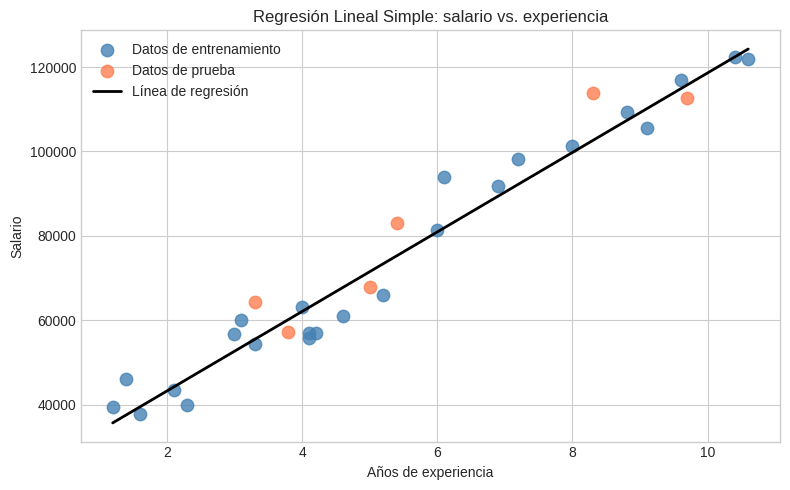

In [ ]:
# Visualizamos los datos de entrenamiento, prueba y la línea de regresión

plt.figure(figsize=(8, 5))

plt.scatter(
    X_train["YearsExperience"],
    y_train,
    color="steelblue",
    s=80,
    alpha=0.8,
    label="Datos de entrenamiento"
)

plt.scatter(
    X_test["YearsExperience"],
    y_test,
    color="coral",
    s=80,
    alpha=0.8,
    label="Datos de prueba"
)

X_linea = np.linspace(
    df["YearsExperience"].min(),
    df["YearsExperience"].max(),
    100
).reshape(-1, 1)

y_linea = modelo.predict(X_linea)

plt.plot(
    X_linea,
    y_linea,
    color="black",
    linewidth=2,
    label="Línea de regresión"
)

plt.title("Regresión Lineal Simple: salario vs. experiencia")
plt.xlabel("Años de experiencia")
plt.ylabel("Salario")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
# Generamos predicciones sobre el conjunto de prueba

y_pred = modelo.predict(X_test)

comparacion = pd.DataFrame({
    "YearsExperience": X_test["YearsExperience"].values,
    "Salary_real": y_test.values,
    "Salary_predicho": y_pred.round(2),
    "Error": (y_test.values - y_pred).round(2)
})

print("Comparación entre salarios reales y predichos:")
display(comparacion)

Comparación entre salarios reales y predichos:


,YearsExperience,Salary_real,Salary_predicho,Error
0,9.7,112636.0,115791.21,-3155.21
1,5.0,67939.0,71499.28,-3560.28
2,8.3,113813.0,102597.87,11215.13
3,5.4,83089.0,75268.80,7820.20
4,3.3,64446.0,55478.79,8967.21
5,3.8,57190.0,60190.70,-3000.70


In [ ]:
# Calculamos las métricas de evaluación

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Métricas del modelo sobre el conjunto de prueba")
print("-" * 55)
print(f"MAE  - Error Absoluto Medio:       {mae:,.2f}")
print(f"MSE  - Error Cuadrático Medio:     {mse:,.2f}")
print(f"RMSE - Raíz del Error Cuadrático:  {rmse:,.2f}")
print(f"R²   - Coeficiente determinación:  {r2:.4f}")

Métricas del modelo sobre el conjunto de prueba
-------------------------------------------------------
MAE  - Error Absoluto Medio:       6,286.45
MSE  - Error Cuadrático Medio:     49,830,096.86
RMSE - Raíz del Error Cuadrático:  7,059.04
R²   - Coeficiente determinación:  0.9024


## Evaluación del modelo

Para evaluar el modelo se han usado las siguientes métricas:

- **MAE**: mide el error absoluto medio entre los salarios reales y los salarios predichos.
- **MSE**: mide el promedio de los errores al cuadrado, penalizando más los errores grandes.
- **RMSE**: es la raíz cuadrada del MSE y se interpreta en las mismas unidades que el salario.
- **R²**: indica qué proporción de la variabilidad del salario es explicada por el modelo.

Un valor de R² cercano a 1 indica que el modelo explica muy bien la relación entre años de experiencia y salario.

## Interpretación de las métricas

El modelo obtiene un **R² de 0.9024** en el conjunto de prueba. Esto significa que la Regresión Lineal Simple explica aproximadamente el **90.24% de la variabilidad del salario** usando únicamente los años de experiencia como variable predictora.

El **MAE es de 6,286.45**, por lo que el modelo se equivoca, en promedio, unos **6,286 dólares** por predicción.

El **RMSE es de 7,059.04**, algo superior al MAE, lo que indica que existen algunos errores más grandes que elevan la penalización cuadrática.

En general, el resultado es bueno porque el R² es superior a 0.90. Sin embargo, el MAE queda por encima de 5,000, por lo que el modelo es útil pero todavía tiene margen de mejora.

In [ ]:
# Calculamos los residuos

residuos = y_test.values - y_pred

analisis_residuos = comparacion.copy()
analisis_residuos["Residuo"] = residuos.round(2)

print("Análisis de residuos:")
display(analisis_residuos)

Análisis de residuos:


,YearsExperience,Salary_real,Salary_predicho,Error,Residuo
0,9.7,112636.0,115791.21,-3155.21,-3155.21
1,5.0,67939.0,71499.28,-3560.28,-3560.28
2,8.3,113813.0,102597.87,11215.13,11215.13
3,5.4,83089.0,75268.80,7820.20,7820.20
4,3.3,64446.0,55478.79,8967.21,8967.21
5,3.8,57190.0,60190.70,-3000.70,-3000.70


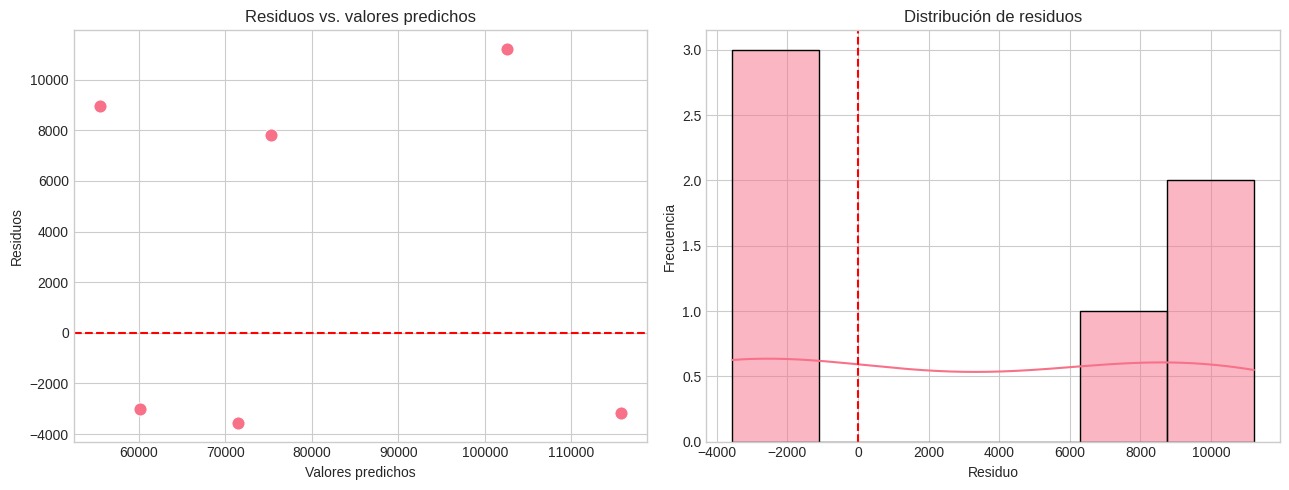

In [ ]:
# Visualizamos los residuos

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

sns.scatterplot(
    x=y_pred,
    y=residuos,
    s=90,
    ax=axes[0]
)

axes[0].axhline(y=0, color="red", linestyle="--")
axes[0].set_title("Residuos vs. valores predichos")
axes[0].set_xlabel("Valores predichos")
axes[0].set_ylabel("Residuos")

sns.histplot(
    residuos,
    bins=6,
    kde=True,
    ax=axes[1]
)

axes[1].axvline(x=0, color="red", linestyle="--")
axes[1].set_title("Distribución de residuos")
axes[1].set_xlabel("Residuo")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

## Análisis de residuos

Los residuos representan la diferencia entre el salario real y el salario predicho por el modelo.

```text
residuo = salario real - salario predicho

In [ ]:
# Evaluamos el rendimiento en entrenamiento y prueba

y_pred_train = modelo.predict(X_train)

r2_train = r2_score(y_train, y_pred_train)
r2_test = r2_score(y_test, y_pred)

print(f"R² en entrenamiento: {r2_train:.4f}")
print(f"R² en prueba:        {r2_test:.4f}")
print(f"Diferencia absoluta: {abs(r2_train - r2_test):.4f}")

if abs(r2_train - r2_test) > 0.10:
    print("Posible overfitting: hay una diferencia considerable entre train y test.")
else:
    print("No se observa overfitting importante: el rendimiento en train y test es parecido.")

R² en entrenamiento: 0.9645
R² en prueba:        0.9024
Diferencia absoluta: 0.0621
No se observa overfitting importante: el rendimiento en train y test es parecido.


In [ ]:
# Validación cruzada con 5 folds

cv_scores = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=5,
    scoring="r2"
)

print("R² por fold:")
print(np.round(cv_scores, 4))

print(f"R² promedio: {cv_scores.mean():.4f}")
print(f"Desviación estándar: {cv_scores.std():.4f}")

R² por fold:
[ 0.3596 -1.2442  0.2505  0.297   0.0703]
R² promedio: -0.0534
Desviación estándar: 0.6032


## Overfitting y validación cruzada

Para detectar posible overfitting se compara el rendimiento del modelo en entrenamiento y en prueba.

El modelo obtiene:

- R² en entrenamiento: **0.9645**
- R² en prueba: **0.9024**
- Diferencia absoluta: **0.0621**

La diferencia entre ambos valores es menor que 0.10, por lo que no se observa un overfitting importante. El modelo mantiene un rendimiento alto tanto en entrenamiento como en prueba.

También se ha aplicado validación cruzada con 5 folds. Los resultados han sido:

```text
R² por fold: [0.3596, -1.2442, 0.2505, 0.2970, 0.0703]
R² promedio: -0.0534
Desviación estándar: 0.6032

In [ ]:
# Validación cruzada con mezcla aleatoria de los datos

from sklearn.model_selection import KFold

kfold = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_scores_shuffle = cross_val_score(
    LinearRegression(),
    X,
    y,
    cv=kfold,
    scoring="r2"
)

print("R² por fold con shuffle:")
print(np.round(cv_scores_shuffle, 4))

print(f"R² promedio con shuffle: {cv_scores_shuffle.mean():.4f}")
print(f"Desviación estándar con shuffle: {cv_scores_shuffle.std():.4f}")

R² por fold con shuffle:
[0.9024 0.9685 0.9162 0.9816 0.8433]
R² promedio con shuffle: 0.9224
Desviación estándar con shuffle: 0.0496


## Interpretación de la validación cruzada con shuffle

Al aplicar validación cruzada con mezcla aleatoria de los datos, los resultados son mucho más estables:

```text
R² por fold con shuffle: [0.9024, 0.9685, 0.9162, 0.9816, 0.8433]
R² promedio con shuffle: 0.9224
Desviación estándar con shuffle: 0.0496

In [ ]:

# Realizamos predicciones para nuevos años de experiencia

nuevos_datos = pd.DataFrame({
    "YearsExperience": [1.5, 5.0, 8.0, 10.0, 12.0]
})

predicciones_nuevas = modelo.predict(nuevos_datos)

resultados_nuevos = pd.DataFrame({
    "YearsExperience": nuevos_datos["YearsExperience"],
    "Salary_predicho": predicciones_nuevas.round(2)
})

print("Predicciones para nuevos datos:")
display(resultados_nuevos)

Predicciones para nuevos datos:


,YearsExperience,Salary_predicho
0,1.5,38515.92
1,5.0,71499.28
2,8.0,99770.72
3,10.0,118618.35
4,12.0,137465.99


## Interpretación de nuevas predicciones

El modelo se ha usado para estimar salarios a partir de nuevos valores de años de experiencia:

| YearsExperience | Salary_predicho |
|---:|---:|
| 1.5 | 38,515.92 |
| 5.0 | 71,499.28 |
| 8.0 | 99,770.72 |
| 10.0 | 118,618.35 |
| 12.0 | 137,465.99 |

Las predicciones siguen la tendencia aprendida por el modelo: a medida que aumentan los años de experiencia, aumenta también el salario estimado.

La predicción para 12 años de experiencia debe interpretarse con más cautela, ya que el valor máximo de experiencia del dataset original es 10.6 años. En ese caso, el modelo está extrapolando fuera del rango observado.

# Conclusiones finales

En esta práctica se ha construido un modelo de **Regresión Lineal Simple** para predecir el salario de un empleado a partir de sus años de experiencia.

El análisis exploratorio mostró una relación positiva muy fuerte entre `YearsExperience` y `Salary`, con una correlación de Pearson de **0.9782**. Esto indicaba que el dataset era adecuado para aplicar un modelo lineal simple.

Tras entrenar el modelo, se obtuvo un **R² de 0.9024** en el conjunto de prueba, lo que significa que el modelo explica aproximadamente el **90.24% de la variabilidad del salario**. El error absoluto medio fue de **6,286.45**, por lo que el modelo se equivoca en promedio en unos **6,286 dólares**.

La comparación entre entrenamiento y prueba mostró:

- R² en entrenamiento: **0.9645**
- R² en prueba: **0.9024**
- Diferencia absoluta: **0.0621**

Esta diferencia no es elevada, por lo que no se observa un overfitting importante.

La validación cruzada sin mezclar los datos produjo resultados inestables, debido probablemente al tamaño reducido del dataset y a que los datos estaban ordenados. Al aplicar `KFold` con `shuffle=True`, el modelo obtuvo un **R² promedio de 0.9224** con una desviación estándar de **0.0496**, lo que confirma un rendimiento bueno y más estable.

En conclusión, la Regresión Lineal Simple funciona bien para este problema. El modelo es interpretable, consigue un buen ajuste y permite estimar salarios de forma razonable usando únicamente los años de experiencia. Aun así, sus predicciones deben interpretarse con cautela cuando se usan valores fuera del rango observado en el dataset.